In [5]:
# PHASE-1

In [6]:
import pandas as pd
#Reading datasets
demo = pd.read_csv("df_final_demo.csv")
web1 = pd.read_csv("df_final_web_data_pt_1.csv")
web2 = pd.read_csv("df_final_web_data_pt_2.csv")
experiment = pd.read_csv("df_final_experiment_clients.csv")



#Merging datasets
web = pd.concat([web1, web2], ignore_index=True)
merge_1 = web.merge(experiment, on="client_id")
df_merged= merge_1.merge(demo, on="client_id")
df_merged.columns = df_merged.columns.str.lower()
df_merged["gendr"] = df_merged["gendr"].replace("nan","Unknown") 

#df_merged.to_csv(r"D:\04_IronHack_DA\IRONHACK_Projects\vanguard_project\df_merged.csv", index=False)
df_merged.head(2)


,client_id,visitor_id,visit_id,process_step,date_time,variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [7]:
#Cleaning merged data

df_merged["variation"]=df_merged["variation"].fillna("results not included")
df_merged["clnt_tenure_yr"]=df_merged["clnt_tenure_yr"].fillna(0.0)
df_merged["clnt_tenure_mnth"]=df_merged["clnt_tenure_mnth"].fillna(0.0)
df_merged["clnt_age"]=df_merged["clnt_age"].fillna(0.0)
df_merged["gendr"]=df_merged["gendr"].fillna("unknown")
df_merged["bal"]=df_merged["bal"].fillna(0.0)
df_merged["calls_6_mnth"]=df_merged["calls_6_mnth"].fillna(0.0)
df_merged["logons_6_mnth"]=df_merged["logons_6_mnth"].fillna(0.0)
df_merged["num_accts"]=df_merged["num_accts"].fillna(0.0)

df_merged["gendr"]=df_merged["gendr"].replace("U","unknown")
df_merged["gendr"]=df_merged["gendr"].replace("X","unknown")


df_merged["date_time"] = pd.to_datetime(df_merged["date_time"],format="%Y-%m-%d %H:%M:%S")
df_merged["date"] = df_merged["date_time"].dt.date
df_merged["time"] = df_merged["date_time"].dt.time


#df_merged.to_csv(r"D:\04_IronHack_DA\IRONHACK_Projects\vanguard_project\df_merged.csv", index=False)


In [8]:
df_merged.head(2)

,client_id,visitor_id,visit_id,process_step,date_time,variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,date,time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,unknown,2.0,189023.86,1.0,4.0,2017-04-17,15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,unknown,2.0,189023.86,1.0,4.0,2017-04-17,15:26:51


In [9]:
#splitting data into test and control groups

test_data = df_merged[df_merged["variation"] == "Test"]
control_data = df_merged[df_merged["variation"] == "Control"]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#Bar plots for the distribution sorted according to age and tenure

#top_age_control = control_data["clnt_age"].value_counts(ascending=False).sort_index().head(80)
#top_tenure_control = control_data["clnt_tenure_yr"].value_counts(ascending=False).sort_index().head(80)
#top_age_test = test_data["clnt_age"].value_counts(ascending=False).sort_index().head(80)
#top_tenure_test = test_data["clnt_tenure_yr"].value_counts(ascending=False).sort_index().head(80)

#Bar plots for the distribution sorted according to freuqnecy of age and tenure
top_age_control = control_data["clnt_age"].value_counts(ascending=False).head(80)
top_tenure_control = control_data["clnt_tenure_yr"].value_counts(ascending=False).head(80)
top_age_test = test_data["clnt_age"].value_counts(ascending=False).head(80)
top_tenure_test = test_data["clnt_tenure_yr"].value_counts(ascending=False).head(80)


# The primary users are relatively older but with relatively low tenure in both control and test groups

Text(0.5, 1.0, 'Top Client Tenure Years in Control Group')

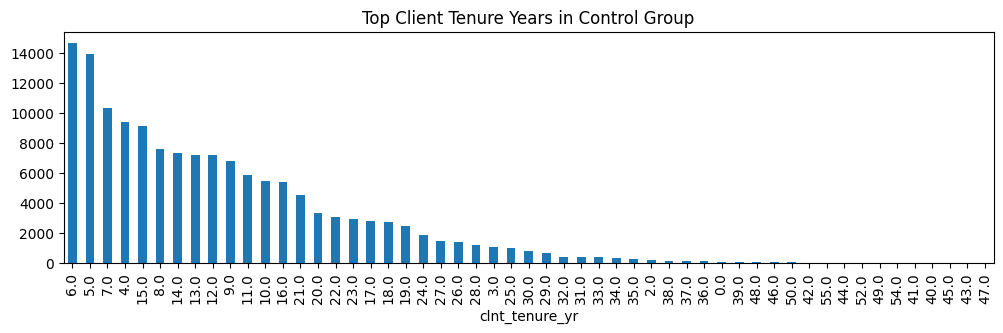

In [11]:
top_tenure_control.plot(kind="bar", figsize=(12, 3))
plt.title("Top Client Tenure Years in Control Group")

Text(0.5, 1.0, 'Top Client Tenure Years in Test Group')

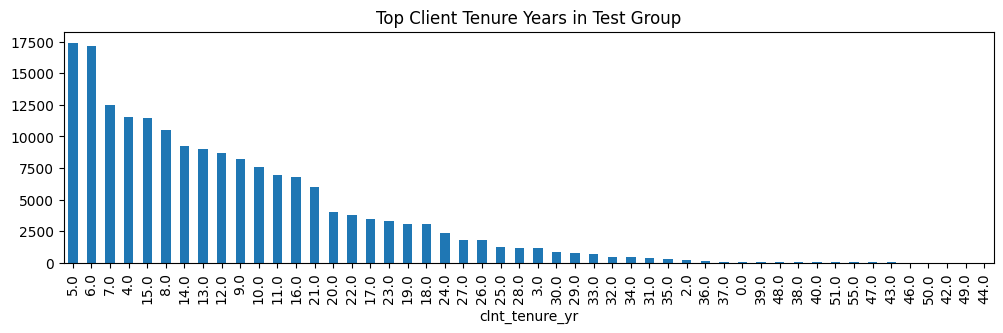

In [12]:
top_tenure_test.plot(kind="bar", figsize=(12, 3))
plt.title("Top Client Tenure Years in Test Group")

Text(0.5, 1.0, 'Top Client Age in Control Group')

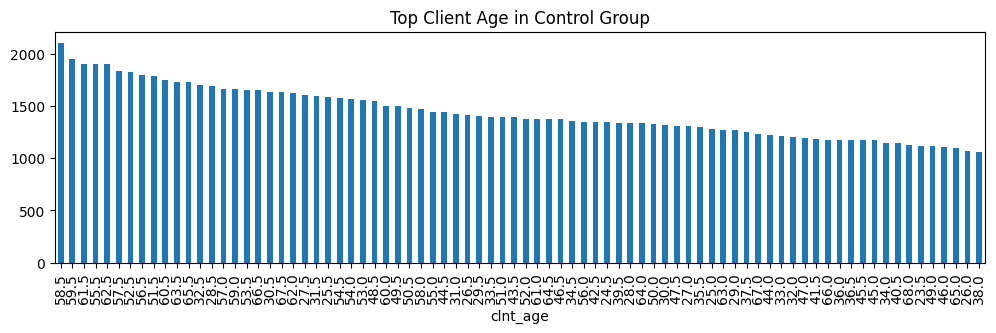

In [13]:
top_age_control.plot(kind="bar", figsize=(12, 3))
plt.title("Top Client Age in Control Group")

Text(0.5, 1.0, 'Top Client Age in Control Group')

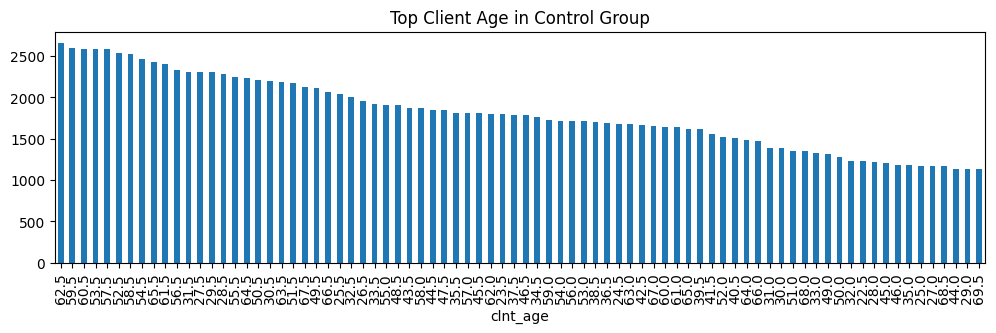

In [14]:
top_age_test.plot(kind="bar", figsize=(12, 3))
plt.title("Top Client Age in Control Group")

In [15]:
#------------------------------------------------------------------------------------------------------

In [16]:
# PHASE-2

In [17]:
#Completion rate test group
total_clients_test = test_data['client_id'].nunique()
confirm_test = test_data[test_data['process_step'] == 'confirm']
total_clients_confirm_test = confirm_test['client_id'].nunique()
completion_rate_test = (total_clients_confirm_test / total_clients_test) * 100
completion_rate_test

69.29323642835953

In [18]:
#Completion rate control group

total_clients_control = control_data['client_id'].nunique()
confirm_control = control_data[control_data['process_step'] == 'confirm']
total_clients_confirm_control = confirm_control['client_id'].nunique()
completion_rate_control = (total_clients_confirm_control / total_clients_control) * 100
completion_rate_control

65.58728539860616

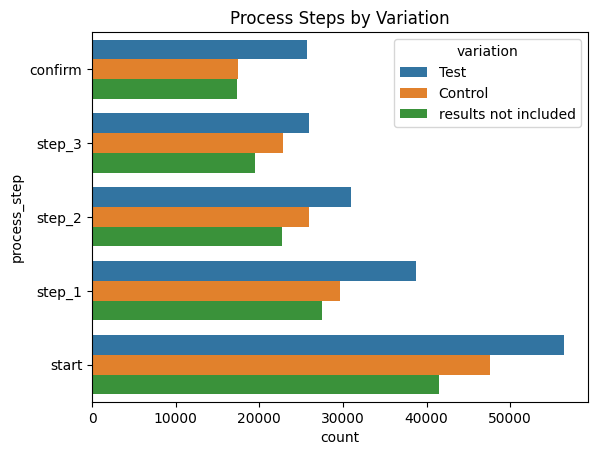

In [19]:
#Visualization of both the groups 
sns.countplot(
    y='process_step',
    hue='variation',
    data=df_merged,
    order= ['confirm','step_3', 'step_2' ,'step_1','start']
)

plt.title("Process Steps by Variation")
plt.show()

<Axes: xlabel='process_step'>

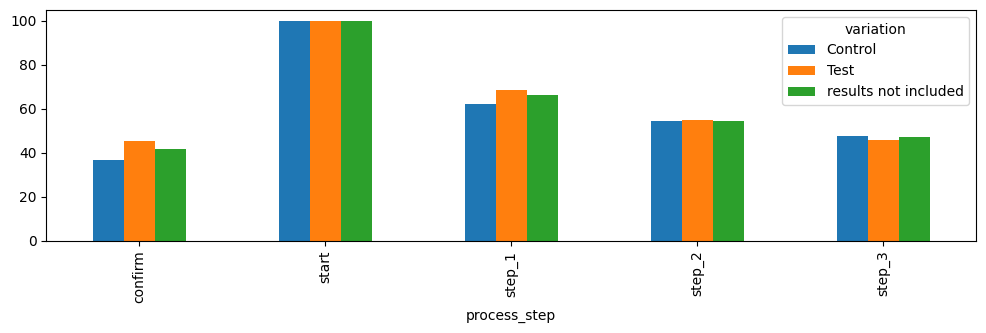

In [20]:
#calculate Retention
process_analysis = pd.crosstab(df_merged['process_step'], df_merged['variation'])

process_analysis_percent = (process_analysis.div(process_analysis.loc['start']) * 100)

process_analysis_percent


process_analysis_percent.plot(kind="bar", figsize=(12, 3))

In [21]:
# Error Rates

step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

def error_rate(data):
    data = data.sort_values(["visit_id", "date_time"]).copy()
    data["step_num"] = data["process_step"].map(step_order)
    
    previous_step = data.groupby("visit_id")["step_num"].shift()
    errors = data["step_num"] < previous_step
    return errors.mean() * 100

test_error_rate = error_rate(test_data)
control_error_rate = error_rate(control_data)

print(f"Test Error Rate: {test_error_rate:.2f}%")
print(f"Control Error Rate: {control_error_rate:.2f}%")

Test Error Rate: 9.17%
Control Error Rate: 6.74%


In [ ]:
data["step_num"] = data["process_step"].map(step_order)
data = data.sort_values(["visit_id", "date_time"])
data["previous_step"] = data.groupby("visit_id")["step_num"].shift()
data["error"] = (data["step_num"] < data["previous_step"]).astype(int)
error_dataset = data[
    [
        "visit_id",
        "client_id",
        "variation",
        "date_time",
        "process_step",
        "step_num",
        "previous_step",
        "error"
    ]
].copy()

In [ ]:
# Average time spent on each process step by variation: add a new column to df_merged as Calculated_Time



In [ ]:
# KPIs Vs Metrics



In [ ]:
# Create a new data frame with: error rate, Average time per step, KPIs (how many people participated in each group) and metrics (how many people actually finished the process)



In [19]:
#------------------------------------------------------------------------------------------------------

In [20]:
# PHASE-3

### Phase3 - Hypothesis Testing

**Null Hypothesis ($H_0$):**

$$
H_0: p_{Test} = p_{Control}
$$

The completion rate of the Test group is equal to the completion rate of the Control group.

**Alternative Hypothesis ($H_A$):**

$$
H_A: p_{Test} != p_{Control}
$$

The completion rate of the Test group is greater than the completion rate of the Control group.

In [21]:
#Step 2: Run a Two-Proportion Z-Test
from statsmodels.stats.proportion import proportions_ztest

# Number of completed clients
successes = [
    total_clients_confirm_test,
    total_clients_confirm_control
]

# Total number of clients
sample_sizes = [
    total_clients_test,
    total_clients_control
]

# One-sided test: Test > Control
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=sample_sizes,
    alternative='larger'
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

#Step 3: Decision

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


Z-statistic: 8.8745
P-value: 0.0000000000
Reject the null hypothesis.


Interpretation

The two-proportion z-test indicates that the completion rate difference between the Test and Control groups is statistically significant (p < 0.05). 
Therefore, we reject the null hypothesis and conclude that the new design significantly improves the likelihood that clients complete the process.



#Phase3:Completion Rate with a Cost-Effectiveness Threshold
### Hypothesis Testing: Cost-Effectiveness Threshold Test

Let

$$
\Delta = p_{Test} - p_{Control}
$$

**Null Hypothesis ($H_0$):**

$$
H_0: \Delta \le 0.05
$$

The increase in completion rate is less than or equal to 5%.

**Alternative Hypothesis ($H_A$):**

$$
H_A: \Delta > 0.05
$$

The increase in completion rate exceeds the 5% threshold required for cost-effectiveness.

In [22]:
#Calculate the Observed Improvement
completion_test = total_clients_confirm_test / total_clients_test
completion_control = total_clients_confirm_control / total_clients_control

improvement = completion_test - completion_control

print(f"Observed improvement: {improvement:.4%}")

Observed improvement: 3.7060%


In [23]:
#Compare Against the Business Threshold
threshold = 0.05

if improvement >= threshold:
    print("Meets cost-effectiveness threshold")
else:
    print("Does NOT meet cost-effectiveness threshold")

Does NOT meet cost-effectiveness threshold


## Final Conclusion

| Question | Result |
|----------|--------|
| Is the improvement statistically significant? | ✅ Yes |
| Is the improvement at least 5%? | ❌ No (3.71%) |
| Does it meet Vanguard's cost-effectiveness threshold? | ❌ No |


While the redesign resulted in a **statistically significant improvement** in completion rates, 
the magnitude of the improvement (**3.71%**) falls short of Vanguard's required **5% minimum threshold** for cost-effectiveness.

**Conclusion:** Statistical significance does not necessarily imply business significance. 
 Although the redesign improved completion rates, the gain is not large enough to satisfy Vanguard's business requirement and 
therefore does not justify implementation based on the established threshold.

### Hypothesis Test: Average Client Age

**Null Hypothesis ($H_0$):**

$$
\mu_{Test} = \mu_{Control}
$$

The average age of clients in the Test group is equal to the average age of clients in the Control group.

**Alternative Hypothesis ($H_A$):**

$$
\mu_{Test} \neq \mu_{Control}
$$

The average age of clients in the Test group differs from the average age of clients in the Control group.
    where:

where:

- $\mu_{Test}$ = mean age of clients in the Test group
- $\mu_{Control}$ = mean age of clients in the Control group




In [24]:
from scipy.stats import ttest_ind

In [25]:
## Hypothesis test: Average age across the two groups

#h0 = Average age in both the groups is same
#hA = Average age in both the groups is differenct


test_data_age = test_data["clnt_age"].dropna()
control_data_age = control_data["clnt_age"].dropna()

t_stat, p_value = ttest_ind(test_data_age, control_data_age)

print("Test average age:", test_data_age.mean())
print("Control average age:", control_data_age.mean())
print("p-value:", p_value)


if p_value > 0.05:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypothesis")
#st.ttest_ind(test_data_age,control_data_age, equal_var=False)

Test average age: 48.73357155307652
Control average age: 48.29171139395798
p-value: 1.9174186541389924e-15
We reject the null hypothesis


In [26]:
## Hypothesis test: Average tenure across the two groups

#h0 = Average tenure in both the groups is same
#hA = Average tenure in both the groups is differenct


test_data_tenure = test_data["clnt_tenure_yr"].dropna()
control_data_tenure = control_data["clnt_tenure_yr"].dropna()

t_stat, p_value = ttest_ind(test_data_tenure, control_data_tenure)

print("Test average tenure:", test_data_tenure.mean())
print("Control average tenure:", control_data_tenure.mean())
print("p-value:", p_value)


if p_value > 0.05:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypothesis")

Test average tenure: 12.175948989862073
Control average tenure: 12.168239673223571
p-value: 0.7551243915056441
We are not able to reject the null hypothesis


## PHASE4 Experiment Evaluation

## Design Effectiveness

### 1. Was the experiment well-structured?

The experiment was well-structured as an A/B test, comparing a Control group (old design) with a Test group (new design).
Both groups were evaluated using the same success metric, allowing for a fair comparison of the two interface designs. 
This structure helps isolate the effect of the design change on user completion rates.

### 2. Were clients randomly and equally divided between the old and new designs?

The distribution of clients across the Control and Test groups was examined to assess balance. 
The group sizes were found to be reasonably similar, suggesting that the experiment was designed to provide comparable samples for evaluation. 
Although the dataset does not explicitly confirm the random assignment procedure, the balanced group sizes and similar demographic characteristics indicate that the allocation was likely fair.

### 3. Were there any biases?

Potential sources of bias were assessed by comparing demographic characteristics such as age and tenure between the Control and Test groups.
Statistical tests showed no significant differences between the groups, indicating that they were broadly comparable. 
This reduces the likelihood that demographic factors influenced the observed outcomes. 
However, unmeasured factors such as digital literacy, user behavior, or prior experience with the platform 
may still have affected the results and should be considered when interpreting the findings.

In [3]:
#2. Were clients randomly and equally divided between the old and new designs?

df_merged['variation'].value_counts()

variation
Test       177847
Control    143462
Name: count, dtype: int64

## Duration Assessment

### Was the timeframe of the experiment (from 3/15/2017 to 6/20/2017) adequate to gather meaningful data and insights?

Since the experiment ran from **March 15, 2017 to June 20, 2017** (approximately **97 days**, or just over **three months**), 
we can conclude that the testing period was sufficient to support a reasoned evaluation of the new design.

The duration allowed enough time to collect a substantial number of client interactions and observe user behavior under both the Control and Test conditions.
A three-month period also helps reduce the impact of short-term fluctuations and provides a more representative view of typical client activity.

Furthermore, the extended timeframe increases confidence that the observed differences in completion rates are attributable to the design change rather than random variation. 
The length of the experiment supports reliable statistical analysis and meaningful business insights.

However, without additional information about seasonal patterns, marketing campaigns, or external events during the testing period, 
it is difficult to completely rule out external influences on user behavior. 
Overall, the experiment duration was adequate for drawing statistically meaningful and actionable conclusions.

## Additional Data Needs

### What other data, if available, could enhance the analysis?

While the available dataset provides sufficient information to evaluate the impact of the new design on completion rates, additional data could further strengthen the analysis and provide deeper insights into user behavior.

Some valuable data points include:

- **Device information (desktop, mobile, tablet):** User experience may differ across devices, and the effectiveness of the new design could vary by platform.
- **Session duration and time spent on each step:** This would help determine whether the new design improved efficiency in addition to completion rates.
- **User drop-off points:** Knowing where users abandoned the process would identify specific stages that caused friction and reveal how the redesign affected user navigation.
- **Digital proficiency or prior platform usage:** Experienced users may interact differently with the interface than first-time users.
- **Customer satisfaction or feedback data:** Survey responses or satisfaction scores could provide qualitative insights into the user experience beyond completion metrics.
- **Traffic source or referral channel:** Different user segments may have different behaviors depending on how they arrived at the platform.
- **Historical completion rates before the experiment:** Baseline performance data would help quantify the magnitude of improvement attributable to the redesign.
- **Information on external events or marketing campaigns:** Such factors could influence user behavior during the experiment period and help control for potential confounding effects.

Overall, additional behavioral, demographic, and contextual data would allow for a more comprehensive evaluation of the redesign's effectiveness and help identify which user segments benefited most from the new interface.